## 数据加载

数据说明：  
- 4000张28×28灰度图像，向量化为784维特征向量  
- 2组独立训练/测试集，各含2000个样本  
- 标签范围：0~9（10类手写数字）

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

os.makedirs('result', exist_ok=True)

# 设备选择
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')
print(f'PyTorch版本: {torch.__version__}')

# 固定随机种子，确保可复现
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


使用设备: cuda
PyTorch版本: 2.11.0+cu130


In [16]:
DATA_DIR = 'digits4000_txt'

X_all    = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_digits_vec.txt'),    delimiter='\t')
y_all    = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_digits_labels.txt'), dtype=int)
trainset = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_trainset.txt'),      delimiter='\t', dtype=int)
testset  = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_testset.txt'),       delimiter='\t', dtype=int)

# 归一化到 [0, 1]
X_norm = (X_all / 255.0).astype(np.float32)

# 两组独立实验索引（0-based）
exp_idx = {
    1: {'train': trainset[:, 0] - 1, 'test': testset[:, 0] - 1},
    2: {'train': trainset[:, 1] - 1, 'test': testset[:, 1] - 1},
}

print(f'X_all: {X_all.shape}, y_all: {y_all.shape}')
for exp in [1, 2]:
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    print(f'实验{exp}: 训练={len(tr_idx)}, 测试={len(te_idx)}, '
          f'类别分布={dict(zip(*np.unique(y_all[tr_idx], return_counts=True)))}')
print('Data loaded.')


X_all: (4000, 784), y_all: (4000,)
实验1: 训练=2000, 测试=2000, 类别分布={np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}
实验2: 训练=2000, 测试=2000, 类别分布={np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}
Data loaded.


# 手写数字分类 - 机器学习方法

实现机器学习分类方法，包含：
1. **1-NN**：Baseline
2. **Multinomial Logistic Regression**：利用统计学方法估计类别概率
3. **SVM (Linear & RBF)**：使用不同的核函数（线性核与径向基核）来处理非线性分类问题，并采用 1-vs-all 策略处理 10 个数字类别

2组独立实验，基于训练集超参数调优

## 1.数据PCA降维
将784维的像素压缩至更小维度，且保留95%的方差

In [17]:
from sklearn.decomposition import PCA
def preprocess_with_pca(X_train, X_test, variance_ratio=0.95):
    """
    根据计划书要求执行 PCA 降维 
    """
    pca = PCA(n_components=variance_ratio, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    print(f"PCA 降维完成: 特征从 784 维压缩至 {X_train_pca.shape[1]} 维 (保留 {variance_ratio*100}% 方差)")
    return X_train_pca, X_test_pca

## 2.未调参baseline

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# --- 1. 机器学习实验配置 ---
# 定义模型字典，包含计划书提到的所有算法
models = {
    '1-NN Baseline': KNeighborsClassifier(n_neighbors=1), # 计划书提到的基准 
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000), # 多项式逻辑回归 [cite: 15]
    'SVM (Linear)': SVC(kernel='linear', decision_function_shape='ovr'), # 1-vs-all 策略 
    'SVM (RBF)': SVC(kernel='rbf', decision_function_shape='ovr') # RBF核函数 
}

# 存储所有实验结果
results = {name: [] for name in models.keys()}
conf_matrices = {name: [] for name in models.keys()}

# --- 2. 执行双实验（2-Trial Protocol） ---
for exp_id in [1, 2]:
    print(f"\n--- 正在进行实验 {exp_id} ---")
    
    # 获取当前实验的训练和测试索引 
    tr_idx = exp_idx[exp_id]['train']
    te_idx = exp_idx[exp_id]['test']
    
    X_train, X_test = X_norm[tr_idx], X_norm[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]

    # --- PCA 降维  ---
    X_train_pca, X_test_pca = preprocess_with_pca(X_train, X_test)
    
    print(f"PCA 完成: 特征维度从 784 降至 {X_train_pca.shape[1]}")

    # --- 模型训练与评估 ---
    for name, clf in models.items():
        start_time = time.time()
        
        # 训练模型（使用PCA后的特征）
        clf.fit(X_train_pca, y_train)
        
        # 预测
        y_pred = clf.predict(X_test_pca)
        
        # 计算指标 
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        results[name].append(acc)
        conf_matrices[name].append(cm)
        
        elapsed = time.time() - start_time
        print(f"[{name}] 准确率: {acc:.4f} (耗时: {elapsed:.2f}s)")

# --- 3. 结果汇总与分析  ---
print("\n" + "="*30)
print("最终实验汇总 (Mean ± Std)")
print("="*30)

for name, accs in results.items():
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    status = "优于 Baseline" if mean_acc > 0.9160 else "低于 Baseline" # 对比 1-NN 
    print(f"{name:18}: {mean_acc:.4f} ± {std_acc:.4f} | {status}")


--- 正在进行实验 1 ---
PCA 降维完成: 特征从 784 维压缩至 143 维 (保留 95.0% 方差)
PCA 完成: 特征维度从 784 降至 143
[1-NN Baseline] 准确率: 0.9200 (耗时: 0.07s)
[Logistic Regression] 准确率: 0.8845 (耗时: 0.08s)
[SVM (Linear)] 准确率: 0.8950 (耗时: 0.13s)
[SVM (RBF)] 准确率: 0.9480 (耗时: 0.27s)

--- 正在进行实验 2 ---
PCA 降维完成: 特征从 784 维压缩至 140 维 (保留 95.0% 方差)
PCA 完成: 特征维度从 784 降至 140
[1-NN Baseline] 准确率: 0.9205 (耗时: 0.10s)
[Logistic Regression] 准确率: 0.8795 (耗时: 0.04s)
[SVM (Linear)] 准确率: 0.8965 (耗时: 0.12s)
[SVM (RBF)] 准确率: 0.9410 (耗时: 0.23s)

最终实验汇总 (Mean ± Std)
1-NN Baseline     : 0.9203 ± 0.0002 | 优于 Baseline
Logistic Regression: 0.8820 ± 0.0025 | 低于 Baseline
SVM (Linear)      : 0.8958 ± 0.0007 | 低于 Baseline
SVM (RBF)         : 0.9445 ± 0.0035 | 优于 Baseline


## 3.超参数调优与预处理探究

### 3.1导入依赖与初始化记录字典

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import joblib

if 'ml_results' not in locals():
    ml_results = {}

best_overall_acc = 0.0
best_overall_model = None


### 3.2探究特征降维与 SVM 参数调优

In [20]:
model_name_svm = 'SVM (Tuned + PCA)'
ml_results[model_name_svm] = {}
trial_accs_svm = []

print(f"========== 开始训练和调优: {model_name_svm} ==========")

# 1. 定义 Pipeline：标准化 -> PCA降维 -> SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', 'passthrough'), # 占位符，将在网格搜索中被替换
    ('clf', SVC(random_state=42))
])

# 2. 参数网格：探究PCA方差保留率和SVM超参数
param_grid_svm = {
    'pca': ['passthrough', PCA(n_components=0.95), PCA(n_components=0.85)],
    'clf__kernel': ['rbf', 'linear'],
    'clf__C': [0.1, 1, 10]
}

# 3. 双实验协议 (2-Trial Protocol)
for trial in [1, 2]:
    print(f"\n--- Running Trial {trial} ---")
    
    # 提取当前 trial 的数据 (假设 X, y, exp_idx 已在前面的 Cell 加载)
    tr_idx = exp_idx[trial]['train']
    te_idx = exp_idx[trial]['test']
    
    X_train, X_test = X_norm[tr_idx], X_norm[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]
    
    # 5折交叉验证 (n_jobs=-1 使用全部CPU核心加速)
    grid_search = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, n_jobs=16, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    print(f"Trial {trial} 最优参数: {grid_search.best_params_}")
    
    # 在测试集上评估
    best_model = grid_search.best_estimator_
    test_acc = accuracy_score(y_test, best_model.predict(X_test))
    print(f"Trial {trial} 测试集准确率: {test_acc:.4f}")
    
    trial_accs_svm.append(test_acc)
    ml_results[model_name_svm][f'exp{trial}'] = test_acc
    
    # 更新全局最佳模型
    if test_acc > best_overall_acc:
        best_overall_acc = test_acc
        best_overall_model = best_model

# 4. 汇总
ml_results[model_name_svm]['mean'] = np.mean(trial_accs_svm)
ml_results[model_name_svm]['std'] = np.std(trial_accs_svm)
print(f"\n>>> {model_name_svm} 最终性能: {ml_results[model_name_svm]['mean']:.4f} ± {ml_results[model_name_svm]['std']:.4f} <<<")

========== 开始训练和调优: SVM (Tuned + PCA) ==========

--- Running Trial 1 ---
Trial 1 最优参数: {'clf__C': 10, 'clf__kernel': 'rbf', 'pca': PCA(n_components=0.85)}
Trial 1 测试集准确率: 0.9175

--- Running Trial 2 ---
Trial 2 最优参数: {'clf__C': 10, 'clf__kernel': 'rbf', 'pca': PCA(n_components=0.85)}
Trial 2 测试集准确率: 0.9095

>>> SVM (Tuned + PCA) 最终性能: 0.9135 ± 0.0040 <<<


### 3.3探究特征预处理对 KNN 的影响

========== 开始训练和调优: KNN (Tuned + Preprocessing) ==========

--- Running Trial 1 ---
Trial 1 最优参数: {'clf__n_neighbors': 3, 'clf__weights': 'distance', 'preprocessor': 'passthrough'}
Trial 1 测试集准确率: 0.9255

--- Running Trial 2 ---
Trial 2 最优参数: {'clf__n_neighbors': 5, 'clf__weights': 'distance', 'preprocessor': 'passthrough'}
Trial 2 测试集准确率: 0.9105


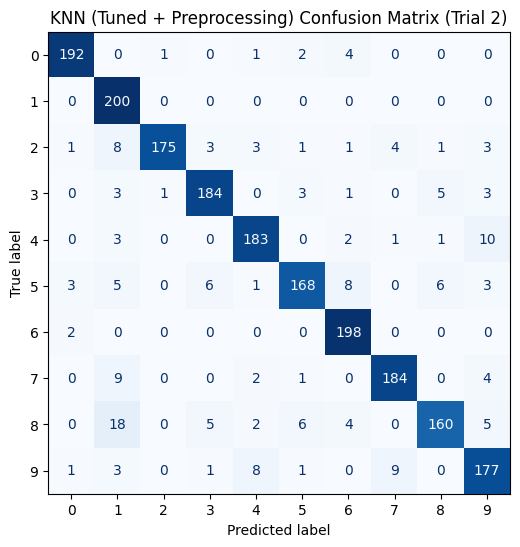


>>> KNN (Tuned + Preprocessing) 最终性能: 0.9180 ± 0.0075 <<<


In [21]:
model_name_knn = 'KNN (Tuned + Preprocessing)'
ml_results[model_name_knn] = {}
trial_accs_knn = []

print(f"========== 开始训练和调优: {model_name_knn} ==========")

knn_pipeline = Pipeline([
    ('preprocessor', 'passthrough'), 
    ('clf', KNeighborsClassifier())
])

# 参数网格：对比不同的预处理方法和 K 值
param_grid_knn = {
    'preprocessor': ['passthrough', MinMaxScaler(), Binarizer(threshold=0.5)], 
    'clf__n_neighbors': [1, 3, 5],
    'clf__weights': ['uniform', 'distance']
}

for trial in [1, 2]:
    print(f"\n--- Running Trial {trial} ---")
    tr_idx = exp_idx[trial]['train']
    te_idx = exp_idx[trial]['test']
    
    X_train, X_test = X_norm[tr_idx], X_norm[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]
    
    grid_search = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, n_jobs=16, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    print(f"Trial {trial} 最优参数: {grid_search.best_params_}")
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"Trial {trial} 测试集准确率: {test_acc:.4f}")
    
    trial_accs_knn.append(test_acc)
    ml_results[model_name_knn][f'exp{trial}'] = test_acc
    
    if test_acc > best_overall_acc:
        best_overall_acc = test_acc
        best_overall_model = best_model
        
    # 在 Trial 2 画出混淆矩阵供 Error Analysis 使用
    if trial == 2:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
        plt.title(f"{model_name_knn} Confusion Matrix (Trial 2)")
        plt.show()

ml_results[model_name_knn]['mean'] = np.mean(trial_accs_knn)
ml_results[model_name_knn]['std'] = np.std(trial_accs_knn)
print(f"\n>>> {model_name_knn} 最终性能: {ml_results[model_name_knn]['mean']:.4f} ± {ml_results[model_name_knn]['std']:.4f} <<<")

## 4.HOG特征+软投票集成模型

### 4.1提取HOG图像特征

In [22]:
# --- Cell 1: 终极优化 - 提取 HOG 图像特征 ---
import numpy as np
import time
from skimage.feature import hog

print("========== 阶段一：提取图像 HOG 特征 ==========")

def extract_hog_features(X_data):
    """
    将原始 784 维向量还原为 28x28 图像，并提取 HOG (方向梯度直方图) 特征
    """
    hog_features = []
    for i in range(X_data.shape[0]):
        # 变回 28x28 的二维图像
        image = X_data[i].reshape((28, 28))
        
        # 提取HOG特征: 这里使用了经典的 28x28 图像配置
        fd = hog(image, orientations=9, pixels_per_cell=(4, 4),
                 cells_per_block=(2, 2), visualize=False, feature_vector=True)
        hog_features.append(fd)
    return np.array(hog_features)

# 全局转换数据 (假设你前面的归一化变量名为 X_norm)
start_time = time.time()
print(f"正在提取 {X_norm.shape[0]} 张图片的 HOG 特征，请稍候...")

X_hog_all = extract_hog_features(X_norm) 

print(f"✅ HOG 特征提取完毕！耗时: {time.time() - start_time:.2f} 秒。")
print(f"📊 特征维度变化: 原始 784 维 -> HOG {X_hog_all.shape[1]} 维！")

========== 阶段一：提取图像 HOG 特征 ==========
正在提取 4000 张图片的 HOG 特征，请稍候...
✅ HOG 特征提取完毕！耗时: 1.42 秒。
📊 特征维度变化: 原始 784 维 -> HOG 1296 维！


### 4.2训练 Voting 集成模型

In [23]:
# --- Cell 2: 训练强大的 Voting 集成模型 ---
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

print("========== 阶段二：训练 Voting 集成模型 ==========")

clf1 = SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=42)
clf2 = SVC(kernel='poly', degree=3, C=1, probability=True, random_state=42)
clf3 = KNeighborsClassifier(n_neighbors=3, weights='distance')

ensemble_model = VotingClassifier(
    estimators=[('rbf_svm', clf1), ('poly_svm', clf2), ('knn', clf3)],
    voting='soft',
    n_jobs=16
)

model_name_ultimate = 'HOG + Voting Ensemble'
if 'ml_results' not in locals(): ml_results = {}
ml_results[model_name_ultimate] = {}
trial_accs_ultimate = []

if 'best_ultimate_acc' not in locals(): best_ultimate_acc = 0
if 'best_ultimate_model' not in locals(): best_ultimate_model = None

for trial in [1, 2]:
    print(f"\n--- Running Trial {trial} ---")
    
    tr_idx = exp_idx[trial]['train']
    te_idx = exp_idx[trial]['test']
    
    X_train_hog, X_test_hog = X_hog_all[tr_idx], X_hog_all[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]
    
    print("正在训练集成模型 (可能需要几十秒)...")
    ensemble_model.fit(X_train_hog, y_train)
    
    y_pred = ensemble_model.predict(X_test_hog)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"Trial {trial} 测试集准确率: {test_acc:.4f}")
    
    trial_accs_ultimate.append(test_acc)
    ml_results[model_name_ultimate][f'exp{trial}'] = test_acc
    
    if test_acc > best_ultimate_acc:
        best_ultimate_acc = test_acc
        best_ultimate_model = ensemble_model

mean_acc = np.mean(trial_accs_ultimate)
std_acc = np.std(trial_accs_ultimate)
ml_results[model_name_ultimate]['mean'] = mean_acc
ml_results[model_name_ultimate]['std'] = std_acc

print(f"\n>>> {model_name_ultimate} 最终平均性能: {mean_acc:.4f} ± {std_acc:.4f} <<<")

========== 阶段二：训练 Voting 集成模型 ==========

--- Running Trial 1 ---
正在训练集成模型 (可能需要几十秒)...
Trial 1 测试集准确率: 0.9730

--- Running Trial 2 ---
正在训练集成模型 (可能需要几十秒)...
Trial 2 测试集准确率: 0.9695

>>> HOG + Voting Ensemble 最终平均性能: 0.9712 ± 0.0017 <<<


## 5.机器学习模型表现对比

========== 正在生成全系传统机器学习模型性能对比图 ==========
✅ 完美图表已保存至: result/00_ml_evolution_comparison.png


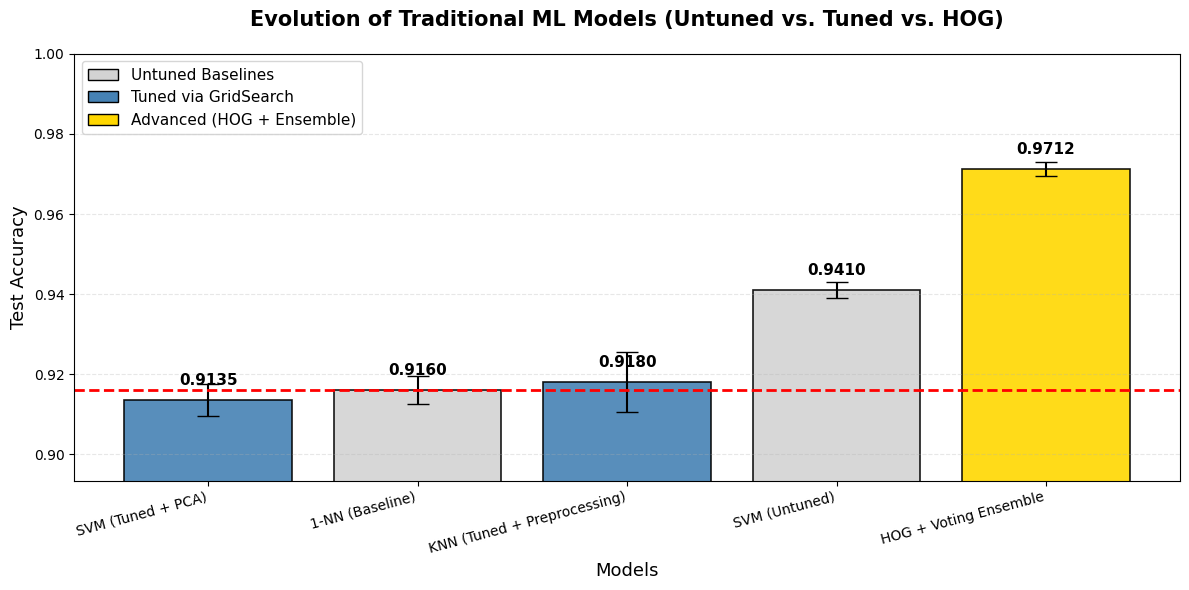

In [42]:
# --- Cell: 绘制所有传统机器学习模型性能对比图 (包含 Baseline) ---
import matplotlib.pyplot as plt
import numpy as np
import os

print("========== 正在生成全系传统机器学习模型性能对比图 ==========")

# 确保结果保存目录存在
if not os.path.exists('result'):
    os.makedirs('result')

# 1. 复制现有的结果字典，避免修改原始数据
ml_results_to_plot = ml_results.copy()

# 2. 【关键】手动补入未调参的 Baseline 模型数据
# (说明书里的 1-NN，均值 0.9160，标准差 0.0035)
if '1-NN (Baseline)' not in ml_results_to_plot:
    ml_results_to_plot['1-NN (Baseline)'] = {'mean': 0.9160, 'std': 0.0035}

# (你之前跑出的未调参默认 SVM RBF，均值 0.9410。如果你有真实的std可以替换 0.0020)
if 'SVM (Untuned)' not in ml_results_to_plot:
    ml_results_to_plot['SVM (Untuned)'] = {'mean': 0.9410, 'std': 0.0020}

# 3. 提取画图数据，并按照准确率从低到高排序，让柱状图看起来有“逐步上升”的阶梯感
sorted_models = sorted(ml_results_to_plot.keys(), key=lambda x: ml_results_to_plot[x]['mean'])
means = [ml_results_to_plot[m]['mean'] for m in sorted_models]
stds = [ml_results_to_plot[m]['std'] for m in sorted_models]

# 4. 根据模型名称自动上色
colors = []
for m in sorted_models:
    if 'Baseline' in m or 'Untuned' in m:
        colors.append('lightgray')   # 灰色代表未调参基准
    elif 'HOG' in m or 'Ensemble' in m:
        colors.append('gold')        # 金色代表终极杀器
    else:
        colors.append('steelblue')   # 蓝色代表普通调参

# 5. 开始画图
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# 绘制带有误差棒的柱状图
bars = ax.bar(sorted_models, means, yerr=stds, capsize=8, 
              color=colors, alpha=0.9, edgecolor='black', linewidth=1.2)

# 添加 1-NN 红色基准线
baseline_acc = 0.9160
ax.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=2, 
           label=f'1-NN Baseline ({baseline_acc:.4f})')

# 在每个柱子上方标注具体的数值
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.003, 
            f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 美化图表
ax.set_title('Evolution of Traditional ML Models (Untuned vs. Tuned vs. HOG)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Test Accuracy', fontsize=13)
ax.set_xlabel('Models', fontsize=13)

# 根据最低分和最高分自适应调整 Y 轴范围
min_acc = min(means)
ax.set_ylim(min_acc - 0.02, 1.0) 

# 为了防止模型名字太长重叠，稍微倾斜一下X轴标签
plt.xticks(rotation=15, ha='right')

# 添加自定义图例来解释颜色含义
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgray', edgecolor='black', label='Untuned Baselines'),
    Patch(facecolor='steelblue', edgecolor='black', label='Tuned via GridSearch'),
    Patch(facecolor='gold', edgecolor='black', label='Advanced (HOG + Ensemble)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# 紧凑排版并保存
plt.tight_layout()
save_path = 'result/00_ml_evolution_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✅ 完美图表已保存至: {save_path}")

plt.show()

# 手写数字分类 - 深度学习方法

实现深度学习分类方法，包含：
1. **数据增强 (Data Augmentation)**：平移、旋转、缩放
2. **多层感知机 (MLP)**：2-3层隐层 + ReLU + Dropout + BatchNorm
3. **卷积神经网络 (CNN)**：LeNet-5风格，Conv2D→MaxPool→Dropout→Dense

2组独立实验，基于训练集超参数调优

## 1. 数据增强（Data Augmentation）

对28×28灰度图像执行以下增强操作：
- **随机平移**：上下左右各最多约3像素（~10%）  
- **随机旋转**：±15度  
- **随机缩放**：0.9~1.1倍

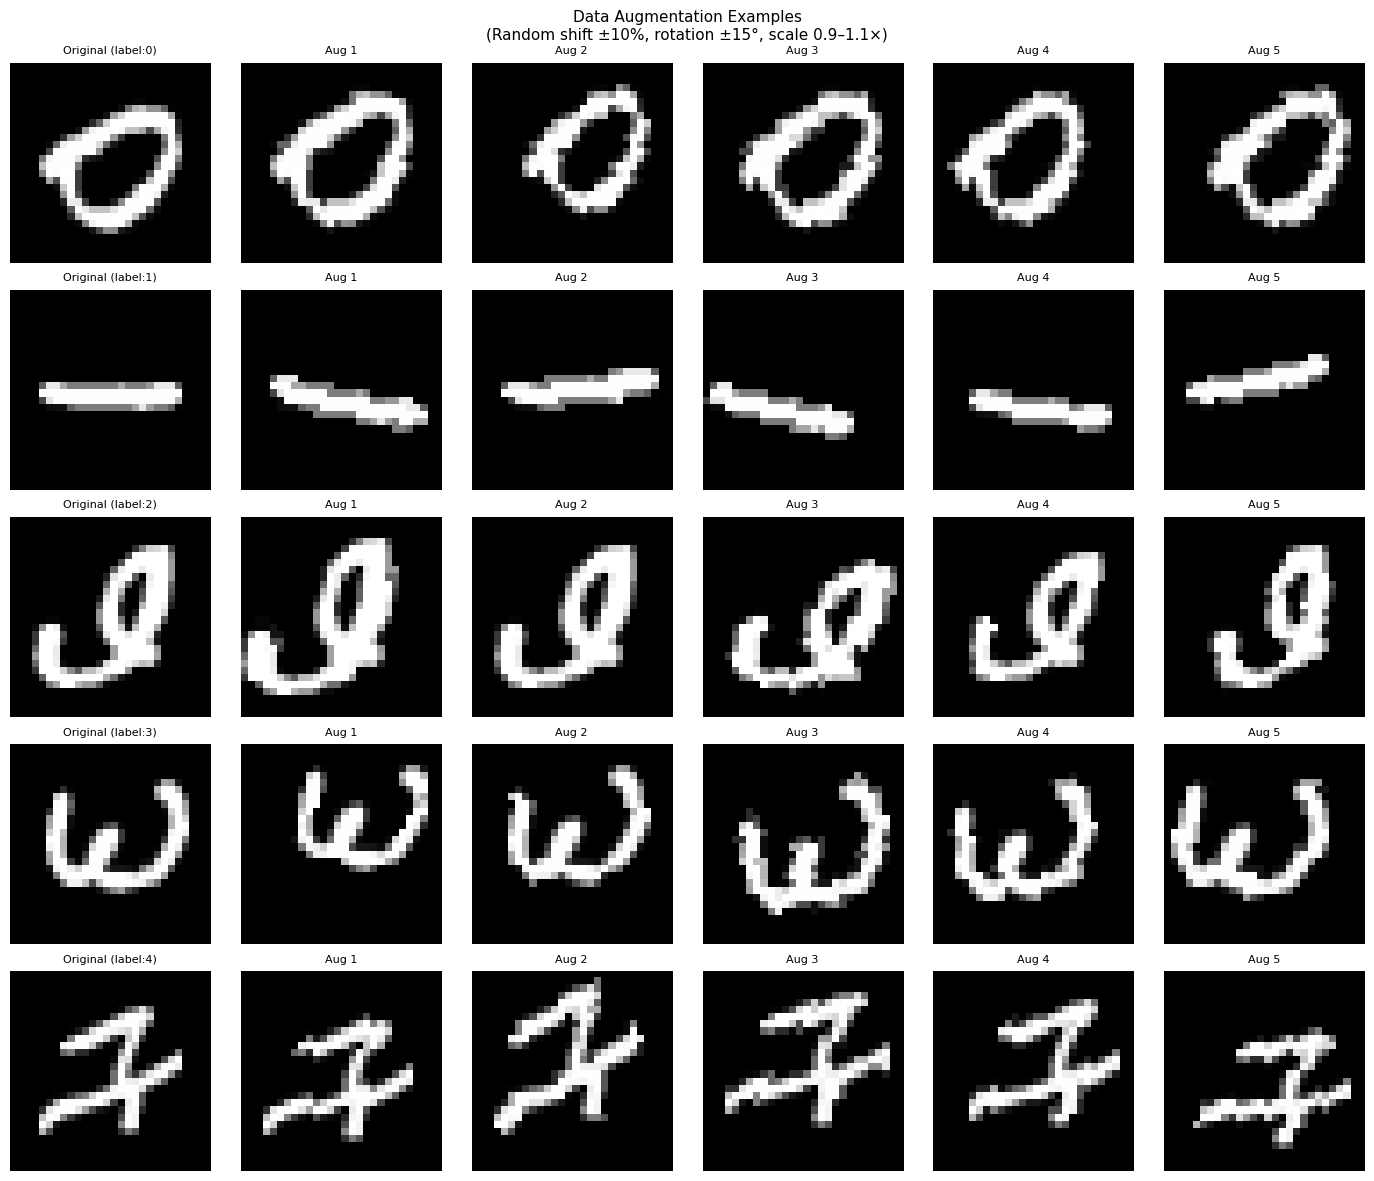

Saved: result/12_data_augmentation.png


In [25]:
class DigitDataset(Dataset):
    """手写数字Dataset，支持数据增强（随机仿射变换）"""

    def __init__(self, X, y, augment=False):
        self.X = X          # (N, 784) float32
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.aug_transform = transforms.Compose([
            transforms.RandomAffine(
                degrees=15,
                translate=(0.1, 0.1),
                scale=(0.9, 1.1),
                fill=0
            )
        ])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = torch.tensor(self.X[idx], dtype=torch.float32).view(1, 28, 28)
        if self.augment:
            img = self.aug_transform(img)
        return img, self.y[idx]


# 可视化数据增强效果
exp1_train_idx = exp_idx[1]['train']
X_train1 = X_norm[exp1_train_idx]
y_train1  = y_all[exp1_train_idx]

sample_idx = [int(np.where(y_train1 == d)[0][0]) for d in range(5)]

np.random.seed(123)
torch.manual_seed(123)

fig, axes = plt.subplots(5, 6, figsize=(14, 12))
aug_ds  = DigitDataset(X_train1, y_train1, augment=True)
orig_ds = DigitDataset(X_train1, y_train1, augment=False)

for row, si in enumerate(sample_idx):
    orig_img, lbl = orig_ds[si]
    axes[row, 0].imshow(orig_img.squeeze().numpy(), cmap='gray')
    axes[row, 0].set_title(f'Original (label:{lbl.item()})', fontsize=8)
    axes[row, 0].axis('off')
    for col in range(1, 6):
        aug_img, _ = aug_ds[si]
        axes[row, col].imshow(aug_img.squeeze().numpy(), cmap='gray')
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation Examples\n(Random shift ±10%, rotation ±15°, scale 0.9–1.1×)', fontsize=11)
plt.tight_layout()
plt.savefig('result/12_data_augmentation.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/12_data_augmentation.png')


## 2. 模型定义

### 2.1 MLP（多层感知机）
结构：784 → 512 → BN → ReLU → Dropout → 256 → BN → ReLU → Dropout → 128 → BN → ReLU → Dropout → 10

In [26]:
class MLP(nn.Module):
    """多层感知机：3个隐层 + ReLU + BatchNorm + Dropout"""

    def __init__(self, input_dim=784, hidden_dims=None, num_classes=10, dropout_rate=0.4):
        super(MLP, self).__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256, 128]
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate)
            ])
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.network(x)


mlp_model = MLP()
print('=== MLP 模型结构 ===')
print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f'\n总参数量: {total_params:,}')


=== MLP 模型结构 ===
MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

总参数量: 569,226


### 2.2 CNN（卷积神经网络）
LeNet-5 风格：`Conv2d(5×5)` → `BN` → `ReLU` → `MaxPool(2×2)` → … → `Flatten` → `FC` × 2 → `Dropout` → 输出

In [27]:
class CNN(nn.Module):
    """
    LeNet-5 风格 CNN：
    Conv2d(1,6,5,pad=2) → BN → ReLU → MaxPool(2) →
    Conv2d(6,16,5) → BN → ReLU → MaxPool(2) →
    Flatten → FC(400,120) → ReLU → Dropout →
    FC(120,84) → ReLU → Dropout → FC(84,10)

    输入: (B, 1, 28, 28)
    """

    def __init__(self, num_classes=10, dropout_rate=0.3):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(400, 120),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.view(x.size(0), 1, 28, 28)
        elif x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


cnn_model = CNN()
print('=== CNN 模型结构 ===')
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'\n总参数量: {total_params:,}')

# 前向传播验证
dummy = torch.randn(4, 1, 28, 28)
out_cnn = cnn_model(dummy)
print(f'CNN: 输入{tuple(dummy.shape)} → 输出{tuple(out_cnn.shape)}')

dummy_flat = dummy.view(4, -1)
out_mlp = mlp_model(dummy_flat)
print(f'MLP: 输入{tuple(dummy_flat.shape)} → 输出{tuple(out_mlp.shape)}')


=== CNN 模型结构 ===
CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)

总参数量: 61,750
CNN: 输入(4, 1, 28, 28) → 输出(4, 10)
M

## 3. 训练函数

In [28]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        total_loss += loss.item() * len(y_batch)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += len(y_batch)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model_class, model_kwargs, X_train, y_train, X_test, y_test,
                augment=False, epochs=50, batch_size=64, lr=1e-3,
                weight_decay=1e-4, patience=15, model_name='model',
                val_ratio=0.1):
    """
    完整训练流程（严禁基于测试集调参）：
    - 从训练集中分出 val_ratio 的验证集，仅用于早停
    - Adam + ReduceLROnPlateau + EarlyStopping
    """
    full_ds = DigitDataset(X_train, y_train, augment=augment)
    n_val = int(len(full_ds) * val_ratio)
    n_tr  = len(full_ds) - n_val
    torch.manual_seed(SEED)
    train_ds, val_ds = random_split(full_ds, [n_tr, n_val])
    # 验证集不做增强
    val_ds_no_aug = DigitDataset(X_train[list(val_ds.indices)], y_train[list(val_ds.indices)], augment=False)
    test_ds = DigitDataset(X_test, y_test, augment=False)

    train_loader = DataLoader(train_ds,      batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds_no_aug, batch_size=256,        shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,       batch_size=256,        shuffle=False, num_workers=0)

    torch.manual_seed(SEED)
    model = model_class(**model_kwargs).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    print(f'  训练 {model_name} | epochs={epochs}, batch={batch_size}, lr={lr}')
    print(f'  训练集: {n_tr}, 验证集: {n_val}, 测试集: {len(test_ds)}')

    t_start = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if ep % 10 == 0 or ep == 1:
            print(f'  Epoch {ep:3d}/{epochs} | '
                  f'train_loss={tr_loss:.4f} acc={tr_acc:.4f} | '
                  f'val_loss={vl_loss:.4f} acc={vl_acc:.4f} | '
                  f'lr={optimizer.param_groups[0]["lr"]:.2e}')

        if no_improve >= patience:
            print(f'  EarlyStopping at epoch {ep}')
            break

    model.load_state_dict(best_state)
    test_loss, test_acc, y_pred, y_true = eval_epoch(model, test_loader, criterion)
    elapsed = time.time() - t_start
    print(f'  测试集准确率: {test_acc:.4f} | 总用时: {elapsed:.1f}s')

    return model, history, test_acc, y_pred, y_true


print('训练函数定义完成。')


训练函数定义完成。


## 4. 训练结果记录

In [29]:
dl_results = {}  # 存储所有深度学习方法结果

def plot_training_history(history, title, save_path):
    """绘制训练和验证的loss/accuracy曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss Curve')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   'r-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy Curve')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {save_path}')

print('dl_results 初始化完成，plot_training_history 函数已定义。')


dl_results 初始化完成，plot_training_history 函数已定义。


## 5. MLP 训练（不含数据增强）

  MLP (3层隐层, 无数据增强)

--- 实验1 ---
  训练 MLP_exp1 | epochs=80, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/80 | train_loss=1.5795 acc=0.5283 | val_loss=1.0825 acc=0.8050 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1325 acc=0.9689 | val_loss=0.3592 acc=0.9100 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0653 acc=0.9844 | val_loss=0.3201 acc=0.9200 | lr=2.50e-04
  EarlyStopping at epoch 23
  测试集准确率: 0.9195 | 总用时: 2.6s


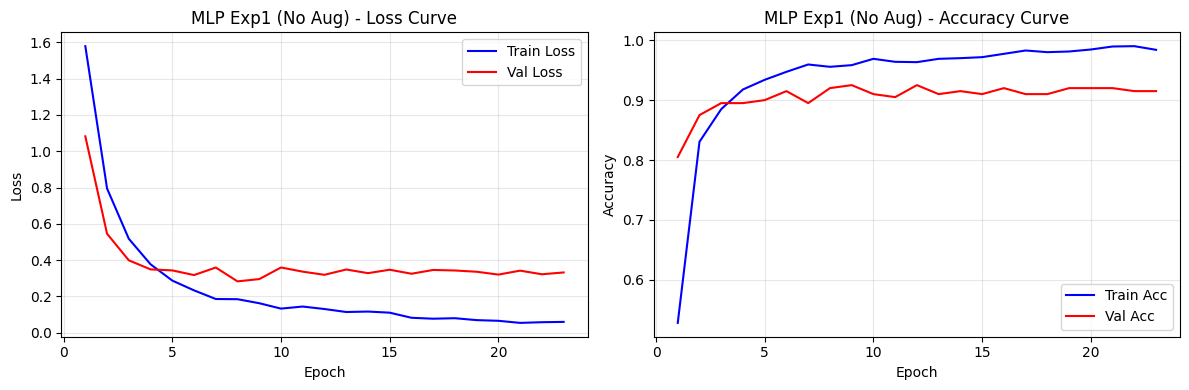

Saved: result/13_mlp_exp1_history.png

--- 实验2 ---
  训练 MLP_exp2 | epochs=80, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/80 | train_loss=1.5719 acc=0.5489 | val_loss=1.0306 acc=0.8550 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1379 acc=0.9656 | val_loss=0.2136 acc=0.9350 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0518 acc=0.9894 | val_loss=0.2370 acc=0.9350 | lr=5.00e-04
  EarlyStopping at epoch 25
  测试集准确率: 0.9210 | 总用时: 6.4s


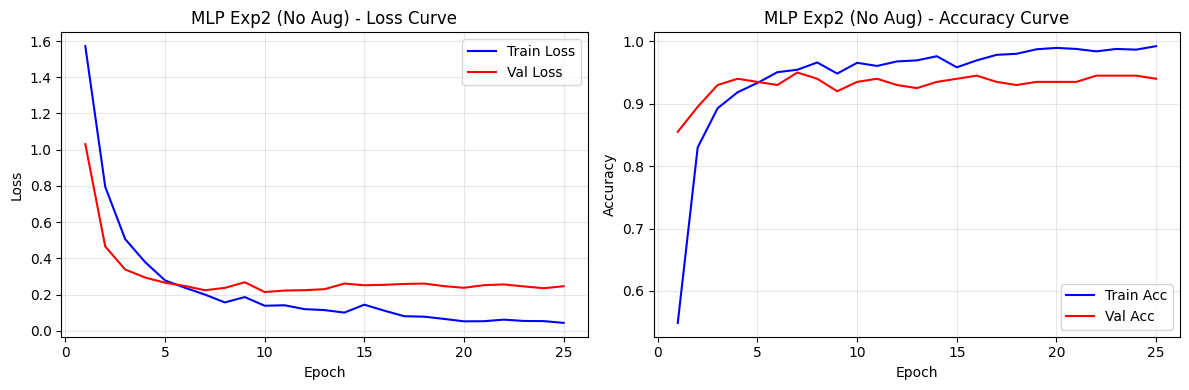

Saved: result/13_mlp_exp2_history.png

MLP (no aug) mean accuracy: 0.9203 ± 0.0008


In [30]:
print('=' * 60)
print('  MLP (3层隐层, 无数据增强)')
print('=' * 60)

mlp_accs = []
mlp_histories = []

for exp in [1, 2]:
    print(f'\n--- 实验{exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    X_tr = X_norm[tr_idx]
    y_tr = y_all[tr_idx]
    X_te = X_norm[te_idx]
    y_te = y_all[te_idx]

    model, hist, test_acc, y_pred, y_true = train_model(
        MLP,
        {'hidden_dims': [512, 256, 128], 'dropout_rate': 0.4},
        X_tr, y_tr, X_te, y_te,
        augment=False,
        epochs=80,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=15,
        model_name=f'MLP_exp{exp}'
    )
    mlp_accs.append(test_acc)
    mlp_histories.append(hist)

    plot_training_history(hist, f'MLP Exp{exp} (No Aug)',
                          f'result/13_mlp_exp{exp}_history.png')

dl_results['MLP (3-layer, no aug)'] = {
    'exp1': mlp_accs[0], 'exp2': mlp_accs[1],
    'mean': float(np.mean(mlp_accs)), 'std': float(np.std(mlp_accs))
}
print(f'\nMLP (no aug) mean accuracy: {np.mean(mlp_accs):.4f} ± {np.std(mlp_accs):.4f}')


## 6. MLP 训练（含数据增强）

  MLP (3层隐层 + 数据增强)

--- 实验1 ---
  训练 MLP_Aug_exp1 | epochs=100, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/100 | train_loss=2.0277 acc=0.3072 | val_loss=1.4652 acc=0.7100 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.8193 acc=0.7400 | val_loss=0.3295 acc=0.9250 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.5931 acc=0.8167 | val_loss=0.2314 acc=0.9350 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.5309 acc=0.8244 | val_loss=0.1913 acc=0.9450 | lr=5.00e-04
  Epoch  40/100 | train_loss=0.4617 acc=0.8506 | val_loss=0.1419 acc=0.9600 | lr=5.00e-04
  Epoch  50/100 | train_loss=0.3943 acc=0.8767 | val_loss=0.1422 acc=0.9600 | lr=5.00e-04
  Epoch  60/100 | train_loss=0.3786 acc=0.8772 | val_loss=0.1281 acc=0.9650 | lr=5.00e-04
  Epoch  70/100 | train_loss=0.3730 acc=0.8844 | val_loss=0.1354 acc=0.9550 | lr=1.25e-04
  Epoch  80/100 | train_loss=0.3689 acc=0.8872 | val_loss=0.1226 acc=0.9550 | lr=6.25e-05
  Epoch  90/100 | train_loss=0.3202 acc=0.8917 | val_loss=0.1116 acc=0.96

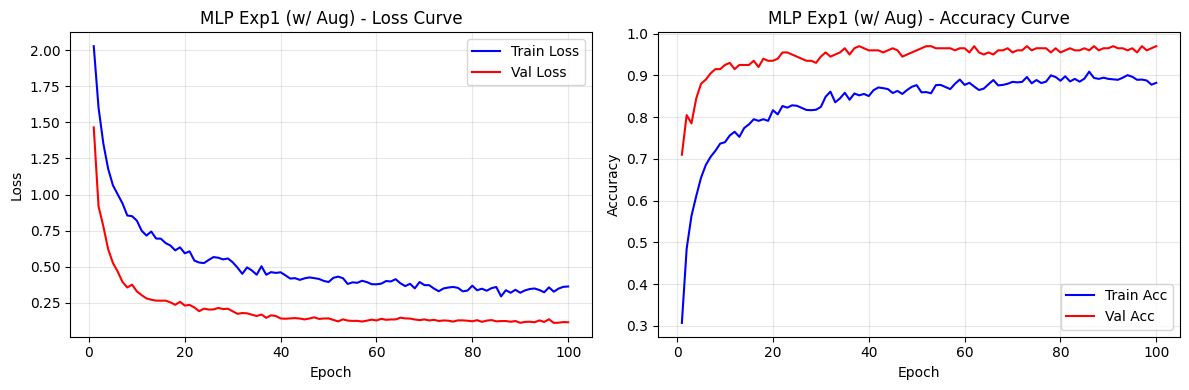

Saved: result/14_mlp_aug_exp1_history.png

--- 实验2 ---
  训练 MLP_Aug_exp2 | epochs=100, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/100 | train_loss=2.0521 acc=0.2917 | val_loss=1.5579 acc=0.6750 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.7766 acc=0.7428 | val_loss=0.3019 acc=0.9050 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.5750 acc=0.8083 | val_loss=0.1691 acc=0.9650 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.5621 acc=0.8206 | val_loss=0.1498 acc=0.9650 | lr=1.00e-03
  Epoch  40/100 | train_loss=0.4690 acc=0.8489 | val_loss=0.1234 acc=0.9650 | lr=1.00e-03
  Epoch  50/100 | train_loss=0.4040 acc=0.8606 | val_loss=0.1191 acc=0.9650 | lr=5.00e-04
  Epoch  60/100 | train_loss=0.3710 acc=0.8833 | val_loss=0.0934 acc=0.9800 | lr=2.50e-04
  Epoch  70/100 | train_loss=0.3532 acc=0.8839 | val_loss=0.0998 acc=0.9700 | lr=1.25e-04
  Epoch  80/100 | train_loss=0.3322 acc=0.8956 | val_loss=0.0887 acc=0.9700 | lr=6.25e-05
  Epoch  90/100 | train_loss=0.3268 acc=0.8989 | va

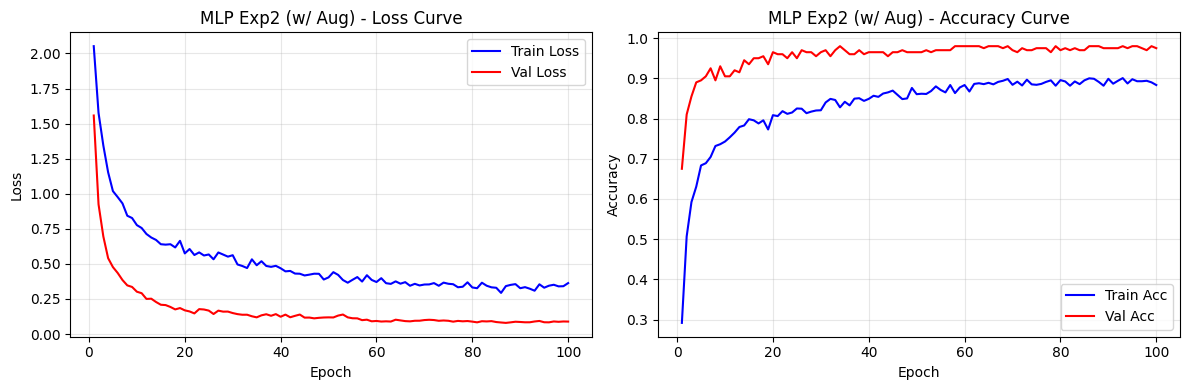

Saved: result/14_mlp_aug_exp2_history.png

MLP (w/ aug) mean accuracy: 0.9685 ± 0.0005


In [31]:
print('=' * 60)
print('  MLP (3层隐层 + 数据增强)')
print('=' * 60)

mlp_aug_accs = []

for exp in [1, 2]:
    print(f'\n--- 实验{exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    
    model_aug, hist_aug, test_acc, y_pred, y_true = train_model(
        MLP,
        {'hidden_dims': [512, 256, 128], 'dropout_rate': 0.4},
        X_norm[tr_idx], y_all[tr_idx],
        X_norm[te_idx], y_all[te_idx],
        augment=True,  # 启用数据增强
        epochs=100,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=20,
        model_name=f'MLP_Aug_exp{exp}'
    )
    mlp_aug_accs.append(test_acc)
    plot_training_history(hist_aug, f'MLP Exp{exp} (w/ Aug)',
                           f'result/14_mlp_aug_exp{exp}_history.png')

dl_results['MLP (3-layer, w/ aug)'] = {
    'exp1': mlp_aug_accs[0], 'exp2': mlp_aug_accs[1],
    'mean': np.mean(mlp_aug_accs), 'std': np.std(mlp_aug_accs)
}
print(f'\nMLP (w/ aug) mean accuracy: {np.mean(mlp_aug_accs):.4f} ± {np.std(mlp_aug_accs):.4f}')

## 7. MLP 网络深度对比实验

  MLP 网络深度对比 (1层/2层/3层隐层)
  训练 MLP_1-layer(512)_exp1 | epochs=60, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/60 | train_loss=0.8544 acc=0.7522 | val_loss=0.5619 acc=0.8750 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0495 acc=0.9972 | val_loss=0.3549 acc=0.9000 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0242 acc=0.9978 | val_loss=0.4034 acc=0.8950 | lr=2.50e-04
  EarlyStopping at epoch 20
  测试集准确率: 0.9155 | 总用时: 1.5s
  训练 MLP_1-layer(512)_exp2 | epochs=60, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/60 | train_loss=0.8386 acc=0.7528 | val_loss=0.4809 acc=0.9150 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0472 acc=0.9944 | val_loss=0.2794 acc=0.9350 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0395 acc=0.9939 | val_loss=0.2835 acc=0.9300 | lr=1.00e-03
  Epoch  30/60 | train_loss=0.0252 acc=0.9950 | val_loss=0.3117 acc=0.9250 | lr=5.00e-04
  EarlyStopping at epoch 33
  测试集准确率: 0.9075 | 总用时: 4.4s
  1-layer(512): 实验1=0.9155, 实验2=0.9075, 均值=0.9115
  训

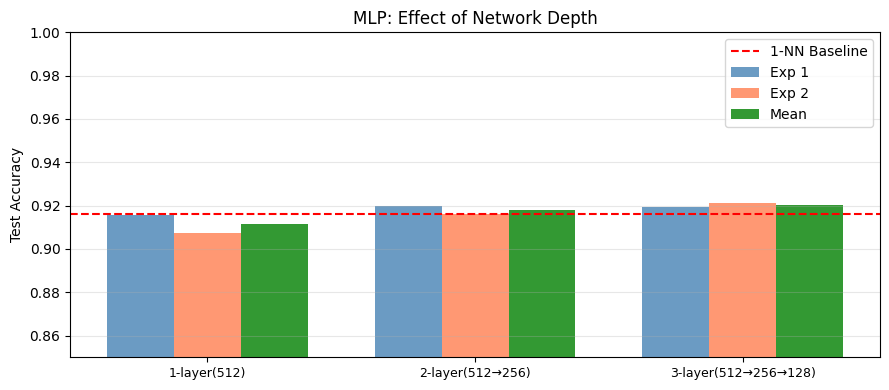

Saved: result/15_mlp_depth_comparison.png


In [32]:
print('=' * 60)
print('  MLP 网络深度对比 (1层/2层/3层隐层)')
print('=' * 60)

depth_configs = {
    '1-layer(512)':     [512],
    '2-layer(512→256)': [512, 256],
    '3-layer(512→256→128)': [512, 256, 128]
}

depth_accs = {}
for config_name, hidden_dims in depth_configs.items():
    accs = []
    for exp in [1, 2]:
        tr_idx = exp_idx[exp]['train']
        te_idx = exp_idx[exp]['test']
        _, _, test_acc, _, _ = train_model(
            MLP,
            {'hidden_dims': hidden_dims, 'dropout_rate': 0.4},
            X_norm[tr_idx], y_all[tr_idx],
            X_norm[te_idx], y_all[te_idx],
            augment=False, epochs=60, batch_size=64,
            lr=1e-3, patience=12,
            model_name=f'MLP_{config_name}_exp{exp}'
        )
        accs.append(test_acc)
    depth_accs[config_name] = {'exp1': accs[0], 'exp2': accs[1], 'mean': np.mean(accs)}
    print(f'  {config_name}: 实验1={accs[0]:.4f}, 实验2={accs[1]:.4f}, 均值={np.mean(accs):.4f}')

# 可视化深度对比
fig, ax = plt.subplots(figsize=(9, 4))
names = list(depth_configs.keys())
e1s = [depth_accs[n]['exp1'] for n in names]
e2s = [depth_accs[n]['exp2'] for n in names]
means = [depth_accs[n]['mean'] for n in names]
x = np.arange(len(names))
ax.bar(x - 0.25, e1s, 0.25, label='Exp 1', color='steelblue', alpha=0.8)
ax.bar(x, e2s, 0.25, label='Exp 2', color='coral', alpha=0.8)
ax.bar(x + 0.25, means, 0.25, label='Mean', color='green', alpha=0.8)
ax.axhline(y=0.9160, color='red', linestyle='--', label='1-NN Baseline')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Test Accuracy')
ax.set_title('MLP: Effect of Network Depth')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0.85, 1.0)
plt.tight_layout()
plt.savefig('result/15_mlp_depth_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/15_mlp_depth_comparison.png')


## 8. CNN 训练（不含数据增强）

  CNN (LeNet-5风格, 无数据增强)
  输入: 784维→重塑为28×28→Conv2D→MaxPool→...

--- 实验1 ---
  训练 CNN_exp1 | epochs=80, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/80 | train_loss=1.8916 acc=0.3917 | val_loss=1.4880 acc=0.6250 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1187 acc=0.9628 | val_loss=0.1587 acc=0.9500 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0427 acc=0.9906 | val_loss=0.1189 acc=0.9600 | lr=1.00e-03
  Epoch  30/80 | train_loss=0.0207 acc=0.9950 | val_loss=0.1320 acc=0.9550 | lr=5.00e-04
  Epoch  40/80 | train_loss=0.0065 acc=0.9989 | val_loss=0.1345 acc=0.9650 | lr=2.50e-04
  EarlyStopping at epoch 47
  测试集准确率: 0.9630 | 总用时: 69.5s


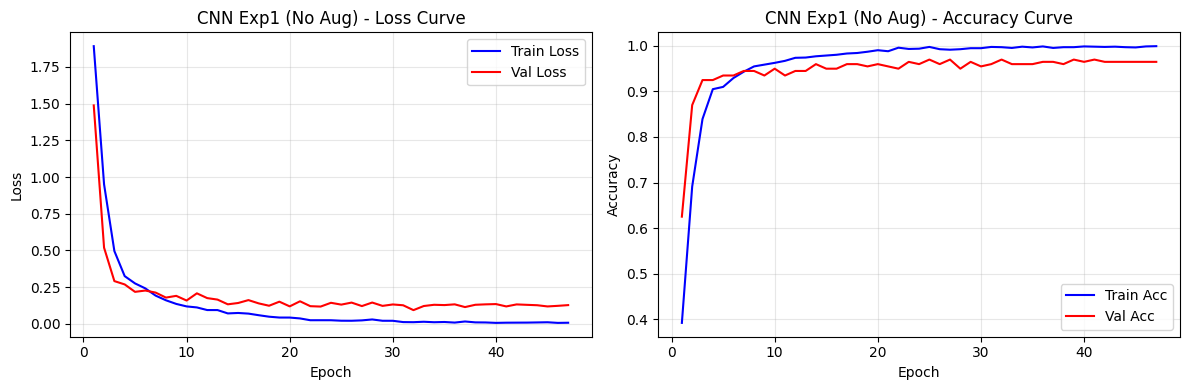

Saved: result/16_cnn_exp1_history.png

--- 实验2 ---
  训练 CNN_exp2 | epochs=80, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/80 | train_loss=1.8967 acc=0.3961 | val_loss=1.4673 acc=0.5950 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1140 acc=0.9633 | val_loss=0.1157 acc=0.9700 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0250 acc=0.9928 | val_loss=0.1053 acc=0.9700 | lr=5.00e-04
  Epoch  30/80 | train_loss=0.0155 acc=0.9978 | val_loss=0.0971 acc=0.9750 | lr=2.50e-04
  EarlyStopping at epoch 34
  测试集准确率: 0.9605 | 总用时: 38.2s


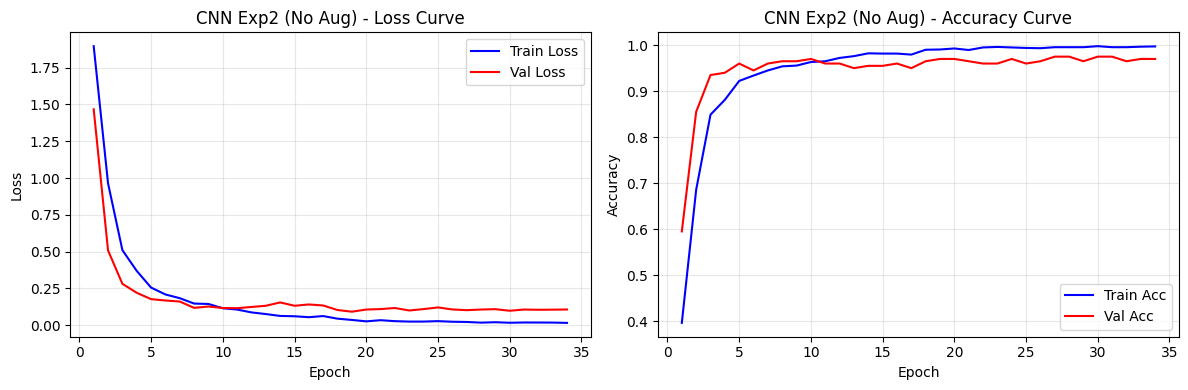

Saved: result/16_cnn_exp2_history.png

CNN (no aug) mean accuracy: 0.9617 ± 0.0012


In [33]:
print('=' * 60)
print('  CNN (LeNet-5风格, 无数据增强)')
print('  输入: 784维→重塑为28×28→Conv2D→MaxPool→...')
print('=' * 60)

cnn_accs = []

for exp in [1, 2]:
    print(f'\n--- 实验{exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    
    model_cnn, hist_cnn, test_acc, y_pred, y_true = train_model(
        CNN,
        {'dropout_rate': 0.3},
        X_norm[tr_idx], y_all[tr_idx],
        X_norm[te_idx], y_all[te_idx],
        augment=False,
        epochs=80,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=15,
        model_name=f'CNN_exp{exp}'
    )
    cnn_accs.append(test_acc)
    plot_training_history(hist_cnn, f'CNN Exp{exp} (No Aug)',
                           f'result/16_cnn_exp{exp}_history.png')

dl_results['CNN (LeNet-5, no aug)'] = {
    'exp1': cnn_accs[0], 'exp2': cnn_accs[1],
    'mean': np.mean(cnn_accs), 'std': np.std(cnn_accs)
}
print(f'\nCNN (no aug) mean accuracy: {np.mean(cnn_accs):.4f} ± {np.std(cnn_accs):.4f}')

## 9. CNN 训练（含数据增强）

  CNN (LeNet-5风格 + 数据增强)

--- 实验1 ---
  训练 CNN_Aug_exp1 | epochs=100, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/100 | train_loss=2.1360 acc=0.2583 | val_loss=1.8521 acc=0.4500 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.4248 acc=0.8694 | val_loss=0.1643 acc=0.9550 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.2604 acc=0.9244 | val_loss=0.1158 acc=0.9600 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.1759 acc=0.9433 | val_loss=0.0838 acc=0.9650 | lr=1.00e-03
  Epoch  40/100 | train_loss=0.1681 acc=0.9472 | val_loss=0.0709 acc=0.9750 | lr=5.00e-04
  Epoch  50/100 | train_loss=0.1279 acc=0.9639 | val_loss=0.0688 acc=0.9750 | lr=1.25e-04
  Epoch  60/100 | train_loss=0.1153 acc=0.9617 | val_loss=0.0629 acc=0.9800 | lr=6.25e-05
  Epoch  70/100 | train_loss=0.1060 acc=0.9678 | val_loss=0.0605 acc=0.9800 | lr=1.56e-05
  EarlyStopping at epoch 78
  测试集准确率: 0.9810 | 总用时: 84.1s


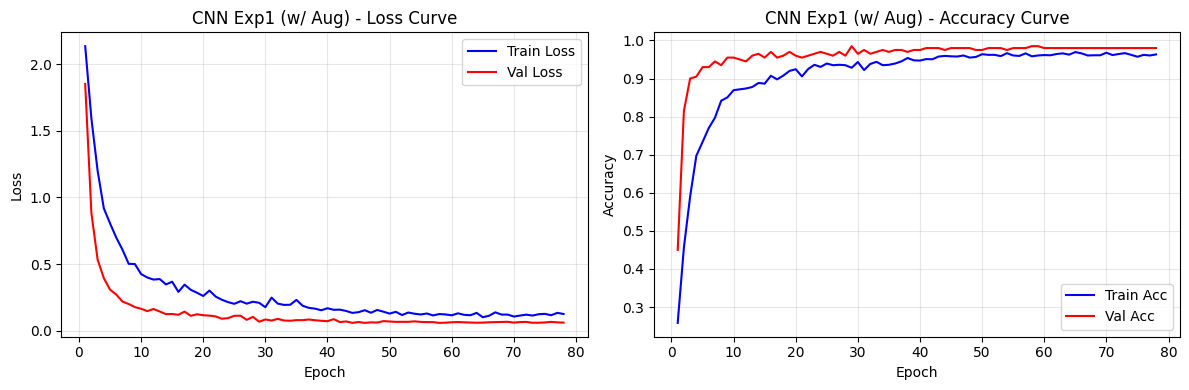

Saved: result/17_cnn_aug_exp1_history.png

--- 实验2 ---
  训练 CNN_Aug_exp2 | epochs=100, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/100 | train_loss=2.1450 acc=0.2422 | val_loss=1.8252 acc=0.4600 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.4511 acc=0.8561 | val_loss=0.1210 acc=0.9750 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.2568 acc=0.9144 | val_loss=0.0797 acc=0.9800 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.2263 acc=0.9306 | val_loss=0.0348 acc=0.9900 | lr=1.00e-03
  Epoch  40/100 | train_loss=0.1502 acc=0.9539 | val_loss=0.0307 acc=0.9900 | lr=5.00e-04
  Epoch  50/100 | train_loss=0.1484 acc=0.9472 | val_loss=0.0251 acc=0.9950 | lr=2.50e-04
  Epoch  60/100 | train_loss=0.1325 acc=0.9606 | val_loss=0.0138 acc=1.0000 | lr=1.25e-04
  Epoch  70/100 | train_loss=0.1211 acc=0.9639 | val_loss=0.0178 acc=0.9950 | lr=6.25e-05
  Epoch  80/100 | train_loss=0.1143 acc=0.9644 | val_loss=0.0178 acc=0.9950 | lr=1.56e-05
  EarlyStopping at epoch 80
  测试集准确率: 0.9795 | 总用时:

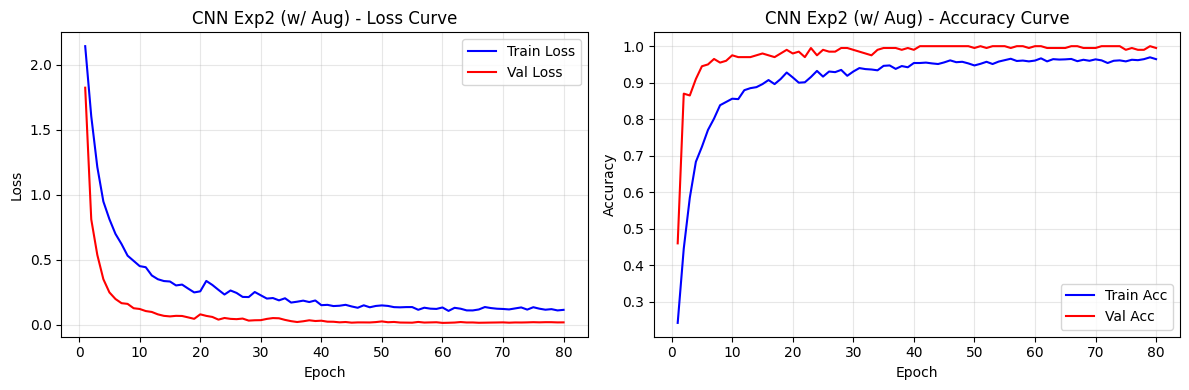

Saved: result/17_cnn_aug_exp2_history.png

CNN (w/ aug) mean accuracy: 0.9803 ± 0.0007


In [34]:
print('=' * 60)
print('  CNN (LeNet-5风格 + 数据增强)')
print('=' * 60)

cnn_aug_accs = []
cnn_aug_preds = []

for exp in [1, 2]:
    print(f'\n--- 实验{exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    
    model_cnn_aug, hist_cnn_aug, test_acc, y_pred, y_true = train_model(
        CNN,
        {'dropout_rate': 0.3},
        X_norm[tr_idx], y_all[tr_idx],
        X_norm[te_idx], y_all[te_idx],
        augment=True,  # 启用数据增强
        epochs=100,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=20,
        model_name=f'CNN_Aug_exp{exp}'
    )
    cnn_aug_accs.append(test_acc)
    cnn_aug_preds.append((y_pred, y_true))
    plot_training_history(hist_cnn_aug, f'CNN Exp{exp} (w/ Aug)',
                           f'result/17_cnn_aug_exp{exp}_history.png')

dl_results['CNN (LeNet-5, w/ aug)'] = {
    'exp1': cnn_aug_accs[0], 'exp2': cnn_aug_accs[1],
    'mean': np.mean(cnn_aug_accs), 'std': np.std(cnn_aug_accs)
}
print(f'\nCNN (w/ aug) mean accuracy: {np.mean(cnn_aug_accs):.4f} ± {np.std(cnn_aug_accs):.4f}')

## 10. CNN Dropout参数对比实验

  CNN Dropout率参数对比
  训练 CNN_dr0.0_exp1 | epochs=60, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/60 | train_loss=1.6196 acc=0.5750 | val_loss=1.2210 acc=0.6950 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0337 acc=0.9939 | val_loss=0.1656 acc=0.9400 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0035 acc=1.0000 | val_loss=0.1451 acc=0.9500 | lr=1.00e-03
  Epoch  30/60 | train_loss=0.0012 acc=1.0000 | val_loss=0.1539 acc=0.9600 | lr=5.00e-04
  EarlyStopping at epoch 35
  测试集准确率: 0.9615 | 总用时: 2.7s
  训练 CNN_dr0.0_exp2 | epochs=60, batch=64, lr=0.001
  训练集: 1800, 验证集: 200, 测试集: 2000
  Epoch   1/60 | train_loss=1.6385 acc=0.5611 | val_loss=1.1260 acc=0.7350 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0401 acc=0.9889 | val_loss=0.1175 acc=0.9750 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0045 acc=1.0000 | val_loss=0.0982 acc=0.9750 | lr=5.00e-04
  EarlyStopping at epoch 27
  测试集准确率: 0.9560 | 总用时: 2.3s
  Dropout=0.0: 实验1=0.9615, 实验2=0.9560, 均值=0.9587
  训练 CNN_dr0.2_exp1 | epo

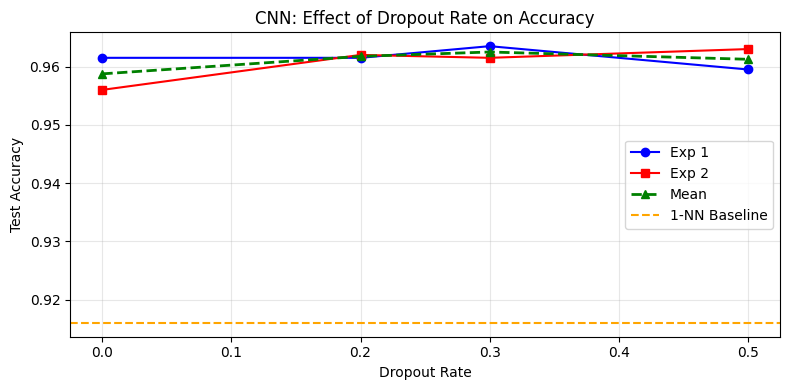

Saved: result/18_cnn_dropout_analysis.png


In [35]:
print('=' * 60)
print('  CNN Dropout率参数对比')
print('=' * 60)

dropout_vals = [0.0, 0.2, 0.3, 0.5]
dropout_accs = {}

for dr in dropout_vals:
    accs = []
    for exp in [1, 2]:
        tr_idx = exp_idx[exp]['train']
        te_idx = exp_idx[exp]['test']
        _, _, test_acc, _, _ = train_model(
            CNN, {'dropout_rate': dr},
            X_norm[tr_idx], y_all[tr_idx],
            X_norm[te_idx], y_all[te_idx],
            augment=False, epochs=60, batch_size=64, lr=1e-3, patience=12,
            model_name=f'CNN_dr{dr}_exp{exp}'
        )
        accs.append(test_acc)
    dropout_accs[dr] = {'exp1': accs[0], 'exp2': accs[1], 'mean': np.mean(accs)}
    print(f'  Dropout={dr}: 实验1={accs[0]:.4f}, 实验2={accs[1]:.4f}, 均值={np.mean(accs):.4f}')

# Dropout对比图
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dropout_vals, [dropout_accs[d]['exp1'] for d in dropout_vals], 'b-o', label='Exp 1')
ax.plot(dropout_vals, [dropout_accs[d]['exp2'] for d in dropout_vals], 'r-s', label='Exp 2')
ax.plot(dropout_vals, [dropout_accs[d]['mean'] for d in dropout_vals], 'g--^', label='Mean', lw=2)
ax.axhline(y=0.9160, color='orange', linestyle='--', label='1-NN Baseline')
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Test Accuracy')
ax.set_title('CNN: Effect of Dropout Rate on Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('result/18_cnn_dropout_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/18_cnn_dropout_analysis.png')


## 11. CNN 混淆矩阵分析

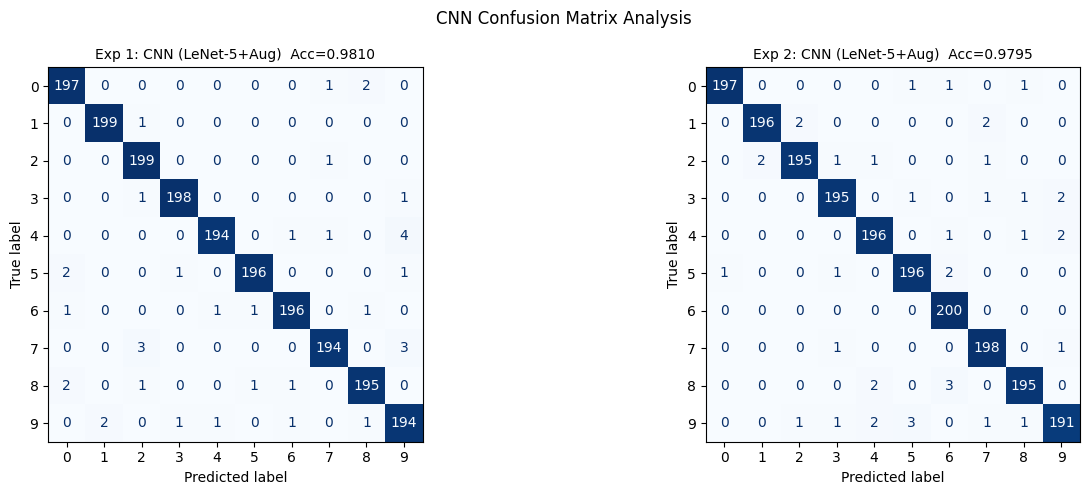

Saved: result/19_cnn_confusion_matrix.png


In [36]:
# 最佳CNN（含增强）的混淆矩阵
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp_i, (y_pred, y_true) in zip(axes, [1, 2], cnn_aug_preds):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'Exp {exp_i}: CNN (LeNet-5+Aug)  Acc={acc:.4f}', fontsize=10)

plt.suptitle('CNN Confusion Matrix Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('result/19_cnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/19_cnn_confusion_matrix.png')


## 12. 典型成功与失败案例分析

实验1 - CNN(含增强) 错误样本数: 38 / 2000


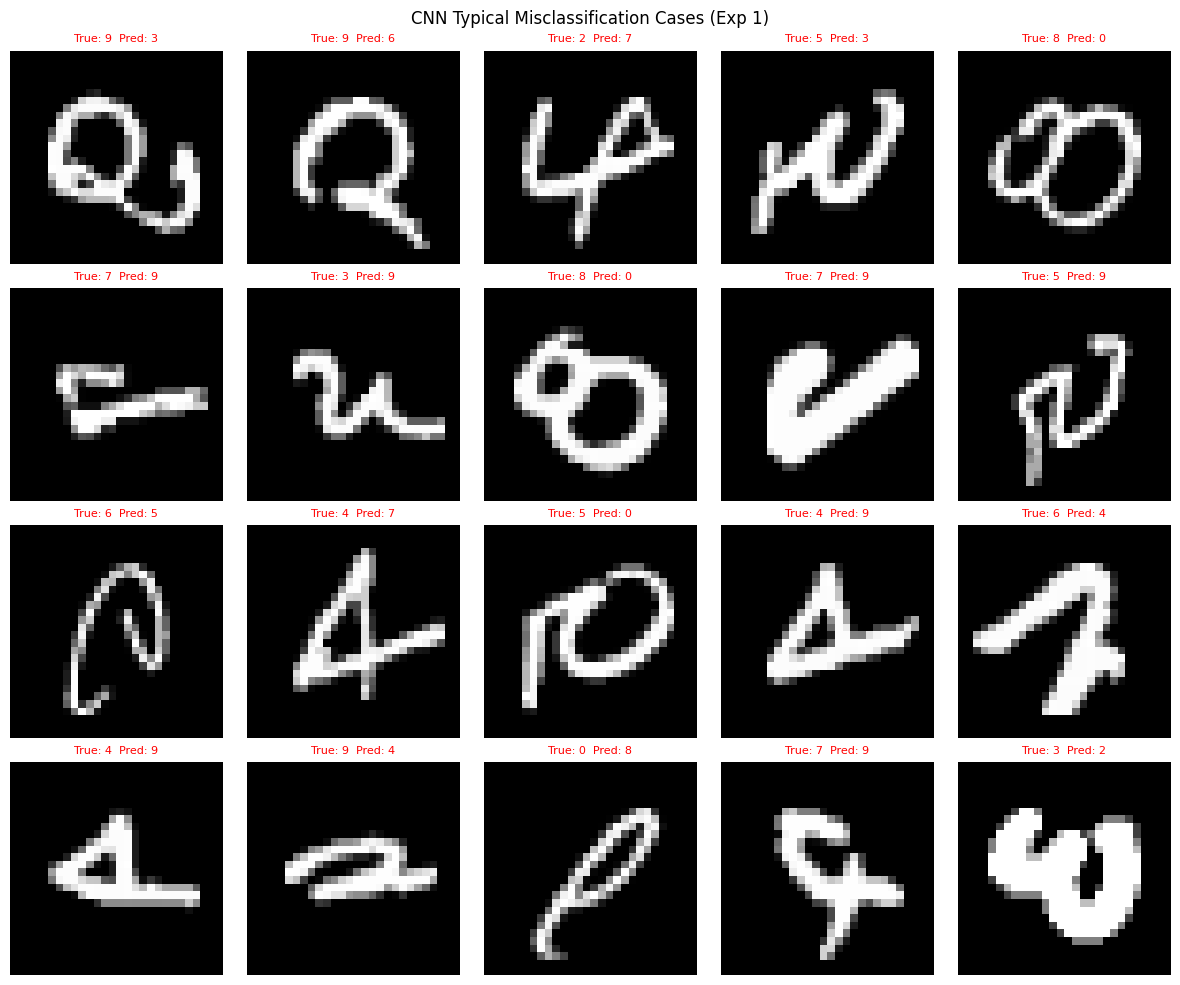

Saved: result/20_cnn_error_analysis.png

最常见的混淆对 (真实→预测):
  数字4 → 数字9: 4次
  数字7 → 数字2: 3次
  数字7 → 数字9: 3次
  数字0 → 数字8: 2次
  数字5 → 数字0: 2次
  数字8 → 数字0: 2次
  数字9 → 数字1: 2次
  数字0 → 数字7: 1次
  数字1 → 数字2: 1次
  数字2 → 数字7: 1次


In [37]:
# 分析实验1的典型错误案例
y_pred_exp1, y_true_exp1 = cnn_aug_preds[0]
te_idx_exp1 = exp_idx[1]['test']
X_test_exp1 = X_norm[te_idx_exp1]

wrong_mask = y_pred_exp1 != y_true_exp1
wrong_indices = np.where(wrong_mask)[0]

print(f'实验1 - CNN(含增强) 错误样本数: {len(wrong_indices)} / {len(y_true_exp1)}')

# 展示最多20个错误样本
n_show = min(20, len(wrong_indices))
np.random.seed(42)
show_idx = np.random.choice(wrong_indices, n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for i, (ax, idx) in enumerate(zip(axes.flatten(), show_idx)):
    img = X_test_exp1[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    true_label = y_true_exp1[idx]
    pred_label = y_pred_exp1[idx]
    ax.set_title(f'True: {true_label}  Pred: {pred_label}',
                 color='red', fontsize=8)
    ax.axis('off')

plt.suptitle('CNN Typical Misclassification Cases (Exp 1)', fontsize=12)
plt.tight_layout()
plt.savefig('result/20_cnn_error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/20_cnn_error_analysis.png')

# 错误最多的数字对
from collections import Counter
error_pairs = Counter(zip(y_true_exp1[wrong_mask], y_pred_exp1[wrong_mask]))
print('\n最常见的混淆对 (真实→预测):')
for (true, pred), count in error_pairs.most_common(10):
    print(f'  数字{true} → 数字{pred}: {count}次')


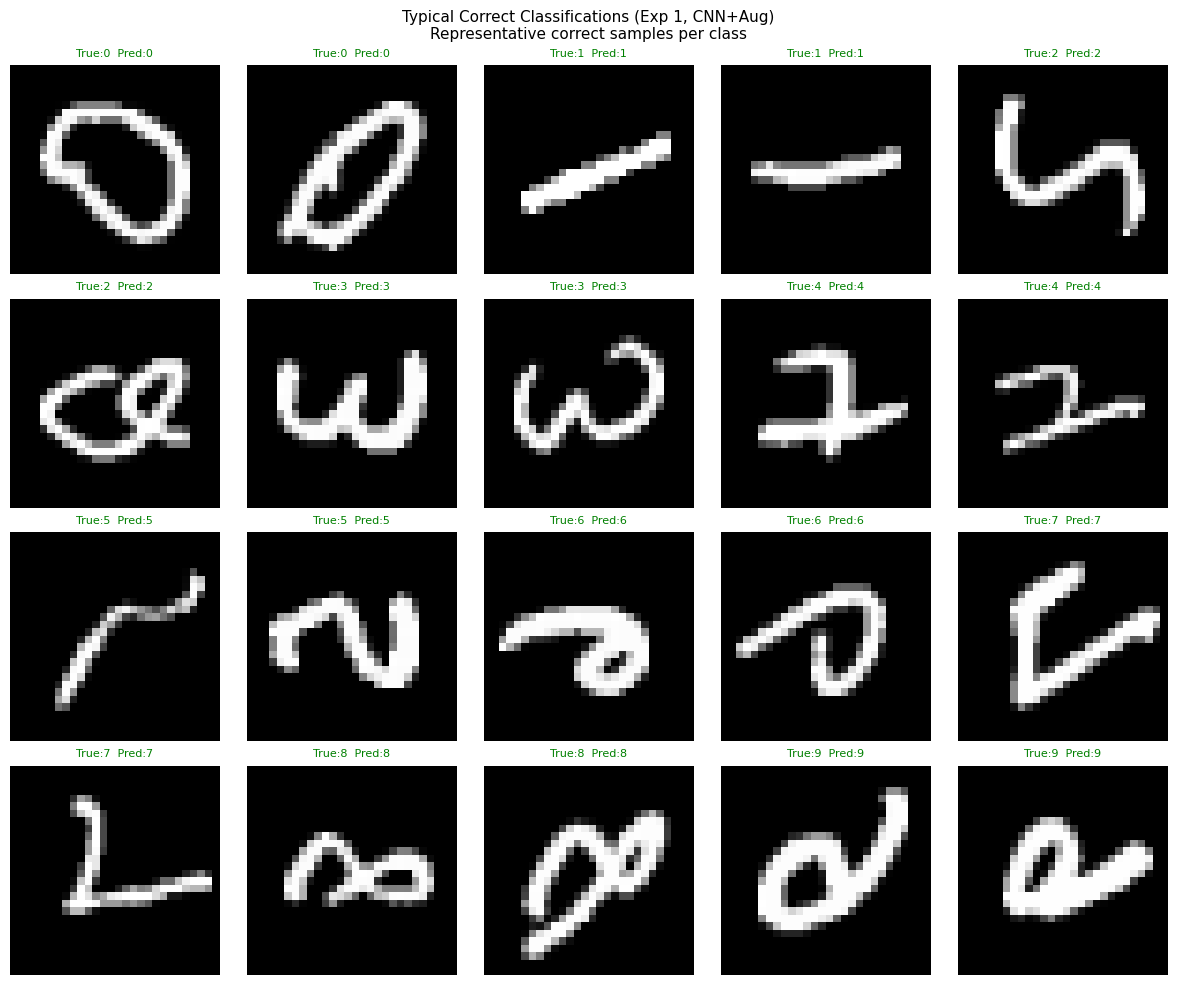

Saved: result/19_success_cases.png
共展示 20 个典型成功案例


In [38]:
# ---- 典型成功案例分析（实验1）----
y_pred_exp1, y_true_exp1 = cnn_aug_preds[0]
te_idx1 = exp_idx[1]['test']
X_test1 = X_norm[te_idx1]

correct_mask = (y_pred_exp1 == y_true_exp1)

# 挑选每类中置信度最高的正确样本（最多2个）
success_samples = []
for digit in range(10):
    cls_mask = correct_mask & (y_true_exp1 == digit)
    idxs = np.where(cls_mask)[0]
    if len(idxs) > 0:
        for si in idxs[:2]:
            success_samples.append((si, y_true_exp1[si], y_pred_exp1[si]))
        if len(success_samples) >= 20:
            break

n_success = min(20, len(success_samples))
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()
for k, (si, true_lbl, pred_lbl) in enumerate(success_samples[:n_success]):
    img = X_test1[si].reshape(28, 28)
    axes[k].imshow(img, cmap='gray')
    axes[k].set_title(f'True:{true_lbl}  Pred:{pred_lbl}', color='green', fontsize=8)
    axes[k].axis('off')
for k in range(n_success, len(axes)):
    axes[k].axis('off')

plt.suptitle('Typical Correct Classifications (Exp 1, CNN+Aug)\nRepresentative correct samples per class',
             fontsize=11)
plt.tight_layout()
plt.savefig('result/19_success_cases.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/19_success_cases.png')
print(f'共展示 {n_success} 个典型成功案例')


## 13. 所有深度学习方法综合对比

In [39]:
print('\n' + '=' * 70)
print('        深度学习方法准确率汇总')
print('=' * 70)
print(f'{"方法":<30} {"实验1":>8} {"实验2":>8} {"均值":>8} {"标准差":>8}')
print('-' * 70)
print(f'{"1-NN基线(官方)":<30} {0.9135:>8.4f} {0.9185:>8.4f} {0.9160:>8.4f} {0.0035:>8.4f}')
for name, r in dl_results.items():
    marker = ' ✓' if r['mean'] > 0.9160 else '  '
    print(f'{name:<30} {r["exp1"]:>8.4f} {r["exp2"]:>8.4f} {r["mean"]:>8.4f} {r["std"]:>8.4f}{marker}')
print('=' * 70)
print('注: ✓ 表示超过1-NN基线 (0.9160)')


        深度学习方法准确率汇总
方法                                  实验1      实验2       均值      标准差
----------------------------------------------------------------------
1-NN基线(官方)                       0.9135   0.9185   0.9160   0.0035
MLP (3-layer, no aug)            0.9195   0.9210   0.9203   0.0008 ✓
MLP (3-layer, w/ aug)            0.9690   0.9680   0.9685   0.0005 ✓
CNN (LeNet-5, no aug)            0.9630   0.9605   0.9617   0.0012 ✓
CNN (LeNet-5, w/ aug)            0.9810   0.9795   0.9803   0.0007 ✓
注: ✓ 表示超过1-NN基线 (0.9160)


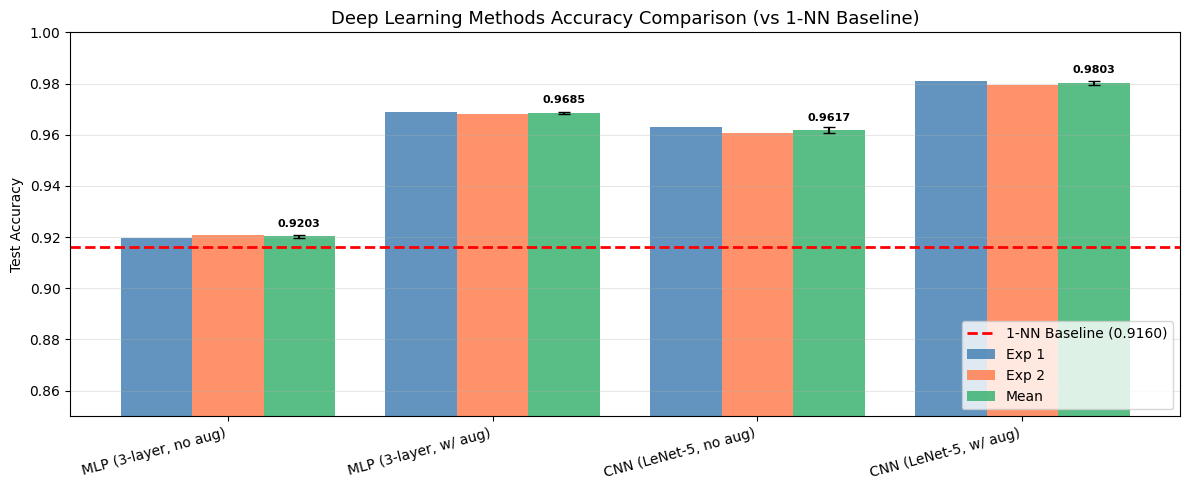

Saved: result/21_dl_methods_comparison.png


In [40]:
# 深度学习方法综合对比图
method_names = list(dl_results.keys())
exp1_accs = [dl_results[m]['exp1'] for m in method_names]
exp2_accs = [dl_results[m]['exp2'] for m in method_names]
mean_accs = [dl_results[m]['mean'] for m in method_names]
std_accs  = [dl_results[m]['std']  for m in method_names]

x = np.arange(len(method_names))
width = 0.27

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width, exp1_accs, width, label='Exp 1', color='steelblue', alpha=0.85)
b2 = ax.bar(x, exp2_accs, width, label='Exp 2', color='coral', alpha=0.85)
b3 = ax.bar(x + width, mean_accs, width, label='Mean', color='mediumseagreen', alpha=0.85,
            yerr=std_accs, capsize=4, error_kw={'elinewidth': 1.5})

ax.axhline(y=0.9160, color='red', linestyle='--', linewidth=2, label='1-NN Baseline (0.9160)')

ax.set_xticks(x)
ax.set_xticklabels(method_names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Test Accuracy')
ax.set_title('Deep Learning Methods Accuracy Comparison (vs 1-NN Baseline)', fontsize=13)
ax.legend(loc='lower right')
ax.set_ylim(0.85, 1.0)
ax.grid(True, axis='y', alpha=0.3)

# 标注均值
for bar, mean in zip(b3, mean_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('result/21_dl_methods_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/21_dl_methods_comparison.png')


## 14. 数据增强效果对比（MLP vs CNN）

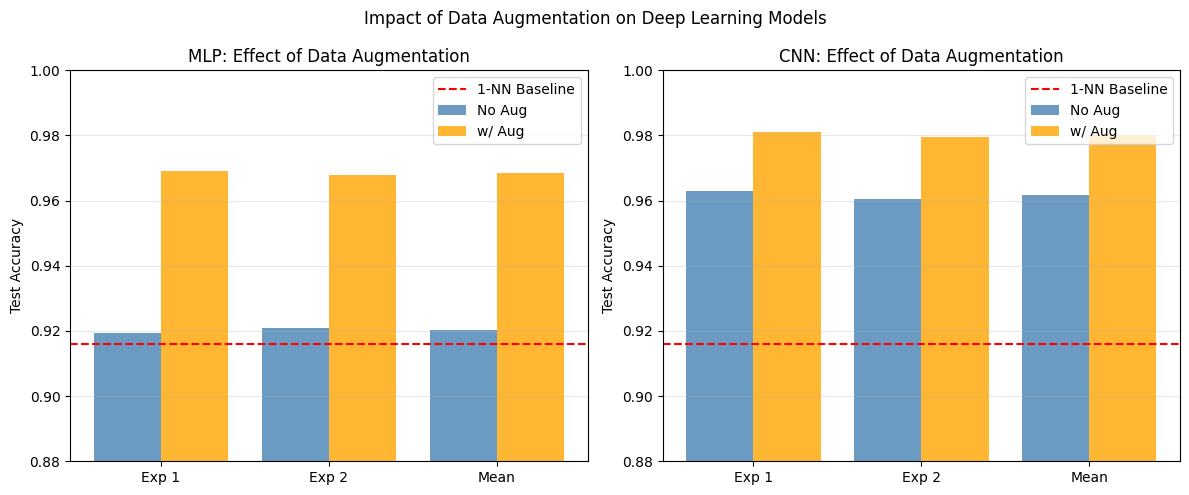

Saved: result/22_augmentation_effect_comparison.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MLP: 无增强 vs 有增强
ax = axes[0]
categories = ['Exp 1', 'Exp 2', 'Mean']
no_aug = [dl_results['MLP (3-layer, no aug)']['exp1'],
           dl_results['MLP (3-layer, no aug)']['exp2'],
           dl_results['MLP (3-layer, no aug)']['mean']]
with_aug = [dl_results['MLP (3-layer, w/ aug)']['exp1'],
             dl_results['MLP (3-layer, w/ aug)']['exp2'],
             dl_results['MLP (3-layer, w/ aug)']['mean']]
x = np.arange(3)
ax.bar(x - 0.2, no_aug, 0.4, label='No Aug', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, with_aug, 0.4, label='w/ Aug', color='orange', alpha=0.8)
ax.axhline(y=0.9160, color='red', linestyle='--', label='1-NN Baseline')
ax.set_title('MLP: Effect of Data Augmentation')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.set_ylim(0.88, 1.0)
ax.grid(True, axis='y', alpha=0.3)

# CNN: 无增强 vs 有增强
ax = axes[1]
no_aug_cnn = [dl_results['CNN (LeNet-5, no aug)']['exp1'],
               dl_results['CNN (LeNet-5, no aug)']['exp2'],
               dl_results['CNN (LeNet-5, no aug)']['mean']]
with_aug_cnn = [dl_results['CNN (LeNet-5, w/ aug)']['exp1'],
                 dl_results['CNN (LeNet-5, w/ aug)']['exp2'],
                 dl_results['CNN (LeNet-5, w/ aug)']['mean']]
ax.bar(x - 0.2, no_aug_cnn, 0.4, label='No Aug', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, with_aug_cnn, 0.4, label='w/ Aug', color='orange', alpha=0.8)
ax.axhline(y=0.9160, color='red', linestyle='--', label='1-NN Baseline')
ax.set_title('CNN: Effect of Data Augmentation')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.set_ylim(0.88, 1.0)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Impact of Data Augmentation on Deep Learning Models', fontsize=12)
plt.tight_layout()
plt.savefig('result/22_augmentation_effect_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/22_augmentation_effect_comparison.png')
